<a href="https://colab.research.google.com/github/MaggieHDez/ClassFiles/blob/PLN/actividad8EmbeddingsMCDH255879.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
# Instalar librerías
# !pip install gensim spacy
# !pip install unidecode
# !python -m spacy download es_core_news_sm

##Entrenar modelo Word2Vec

Ya que se solicita la visualización de palabras, no de frases.

In [74]:
# Importar las librerías
import re
from unidecode import unidecode
import pandas as pd
from sklearn.cluster import KMeans
import spacy
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Leer archivo
def cargar_texto(ruta):
  df = pd.read_csv(ruta)
  return df

# Cargar modelo en español
nlp = spacy.load("es_core_news_sm")

# Función de preprocesamiento
def preprocesar(texto):
    texto = str(texto).lower() # minúsculas
    texto = re.sub(r"[^\w\s]", "", texto) # quitar puntuación
    texto = re.sub(r"\s+", " ", texto).strip() # quitar espacios extras

    doc = nlp(texto) # modelo spacy
    stop = nlp.Defaults.stop_words # carga de los stopwords

    tokens_limpios = [
        tok.lemma_.lower() for tok in doc # Convierte el lema de cada token a minúscula por cada token en doc
        if not tok.is_space and not tok.is_punct and tok.lemma_.lower() not in stop # quita espacios, puntuación y stopwords
    ]
    return tokens_limpios

# Función para recorrer el corpus
def recorrer_corpus(corpus):
    return [preprocesar(doc) for doc in corpus]

# Entrenar Word2Vec
def entrenar_word2vec(corpus):
  modelo_w2v = Word2Vec(
      sentences = corpus,
      vector_size=100,
      window=5,
      min_count=1,
      sg=0,
      workers=4,
      epochs=20)
  print("Modelo Word2Vec entrenado")
  return modelo_w2v

# Ejecutar
if __name__ == "__main__":
  ruta = "/content/drive/MyDrive/ClassFiles/PLN/corpus_5_temas.csv"
  resultado = cargar_texto(ruta)
  corpus = recorrer_corpus(resultado.iloc[:,0])
  modelo_w2v = entrenar_word2vec(corpus)

Modelo Word2Vec entrenado


## Reducir con t-SNE

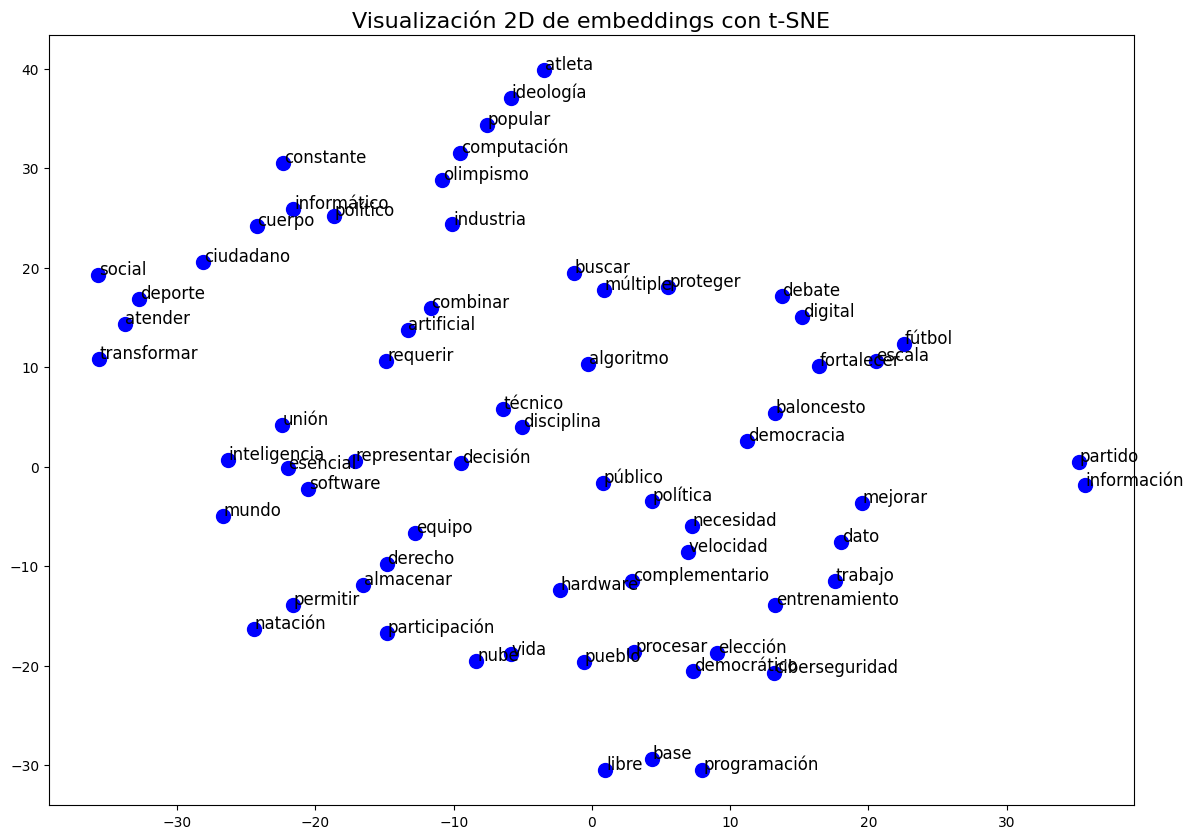

In [90]:
palabras = list(modelo_w2v.wv.index_to_key)

# Obtener embeddings de cada palabra
X = modelo_w2v.wv[palabras]

# Reducir a 2 dimensiones
tsne = TSNE(n_components=2, random_state=42, perplexity=5, init="pca")
X_tsne = tsne.fit_transform(X)

# Visualización
plt.figure(figsize=(14,10))
for i, palabra in enumerate(palabras):
  x, y = X_tsne[i, 0], X_tsne[i, 1]
  plt.scatter(x, y, c="blue", s=100)
  plt.text(x+0.05, y+0.05, palabra, fontsize=12)

plt.title("Visualización 2D de embeddings con t-SNE", fontsize=16)
plt.show()